In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime


========== BOOKSTORE MANAGEMENT ==========

1. Add Book
2. Update Inventory
3. Record Sale
4. View Inventory
5. Sales Analysis
6. NumPy Analysis
7. Visualize Sales
8. Exit


Enter your choice: 7


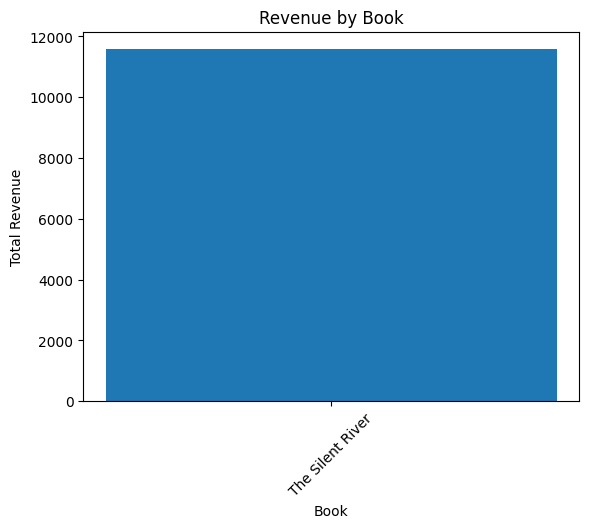

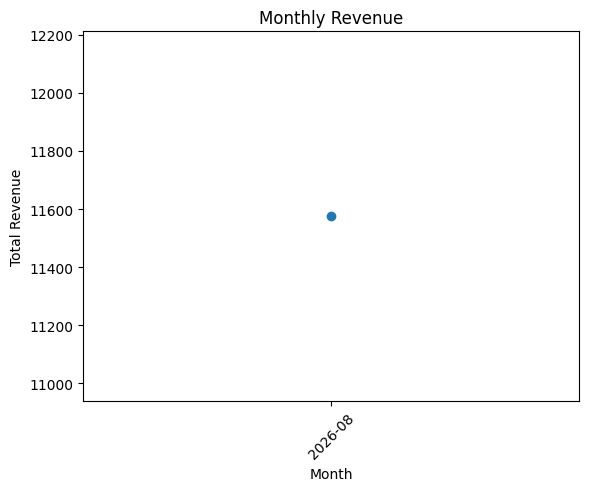

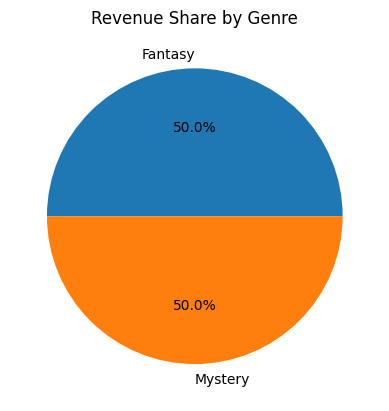


========== BOOKSTORE MANAGEMENT ==========

1. Add Book
2. Update Inventory
3. Record Sale
4. View Inventory
5. Sales Analysis
6. NumPy Analysis
7. Visualize Sales
8. Exit




In [ ]:
class Bookstore:
  def load_csv(self,file_path, sales_filpath):
    self.file_path = file_path
    self.sales_filpath = sales_filpath
    self.df = pd.read_csv(file_path)
    self.salesdf = pd.read_csv(sales_filpath)
    self.clean_data()


  def get_data(self):
    print(self.df)
    print(self.df.loc[self.df["Title"] == "The Silent River","Price"].values[0])


  def add_book(self):
    title = input("Enter the title of the book: ")
    author = input("Enter the author of the book: ")
    genre = input("Enter the genre of the book: ")
    price = float(input("Enter the price of the book: "))
    quantity = int(input("Enter the quantity of the book: "))
    if price < 0:
      print("Price cannot be negative")
      return
    new_book = pd.DataFrame({"Title": [title], "Author": [author], "Genre": [genre], "Price": [price], "Quantity":[quantity]})
    self.df  = pd.concat([self.df,new_book],ignore_index=True)
    pd.DataFrame.to_csv(self.df,self.file_path,index=False)


  def record_sales(self,title,quantity):
    if quantity < 0:
      print("Quantity cannot be negative")
      return
    if(self.df["Title"] == title).any():
      if self.df.loc[self.df["Title"] == title,"Quantity"].values[0] >= quantity :
        self.df.loc[self.df["Title"] == title, "Quantity"] -= quantity
        revenue = self.df.loc[self.df["Title"]==title, "Price"].values[0] * quantity
        now = datetime.now()
        newData = pd.DataFrame({"Date": [now.date()], "Title": [title], "Quantity":[quantity], "Total Revenue":[revenue]})
        self.salesdf = pd.concat([self.salesdf, newData],ignore_index=True)
        self.df.to_csv(self.file_path,index=False)
        self.salesdf.to_csv(self.sales_filpath,index=False)
        print("Sales recorded successfully")
      else:
        print("Not enough books in stock")
    else:
      print("Book not found")


  def clean_data(self):
    self.df["Price"] = pd.to_numeric(self.df["Price"], errors="coerce")
    self.df["Quantity"] = pd.to_numeric(self.df["Quantity"], errors="coerce")
    self.df["Price"] = self.df["Price"].fillna(self.df["Price"].mean())
    self.df["Quantity"] = self.df["Quantity"].fillna(0)
    self.df = self.df[self.df["Price"] > 0]
    self.df = self.df[self.df["Quantity"] >= 0]


  def update_invetory(self,title,quantity):
    if quantity < 0:
      print("Quantity cannot be negative")
      return
    # The truth value of a Series is ambiguous. Use .any() or .all()
    if (self.df["Title"] == title).any():
      self.df.loc[self.df["Title"] == title,"Quantity"] += quantity
    else:
      print("Book not found")
      return
    pd.DataFrame.to_csv(self.df,self.file_path,index=False )


  def sales_analysis(self):
    total_revenue = self.salesdf["Total Revenue"].sum()
    total_books_sold = self.salesdf["Quantity"].sum()
    book_sales = (self.salesdf.groupby("Title")["Quantity"].sum())
    best_book_quantity = book_sales.max()
    sales_with_book = self.salesdf.merge(self.df[["Title","Genre","Author"]],on="Title",how="left")
    genre_sales = sales_with_book.groupby("Genre")["Total Revenue"].sum()
    author_sales = sales_with_book.groupby("Author")["Total Revenue"].sum()
    print("Total Revenue: ",total_revenue)
    print("Total Books Sold: ",total_books_sold)
    print("Best Book Quantity: ",best_book_quantity)
    print("Genre Sales: ",genre_sales)
    print("Author Sales: ",author_sales)

  def numpy_analysis(self):
    quantity = self.salesdf["Quantity"].to_numpy()
    revenue = self.salesdf["Total Revenue"].to_numpy()

    total_quantity = np.sum(quantity)
    total_revenue = np.sum(revenue)
    average_revenue = np.mean(revenue)

    highest_sale = np.max(revenue)
    lowest_sale = np.min(revenue)

    revenue_std = np.std(revenue)

    print("Total Quantity Sold:", total_quantity)
    print("Total Revenue:", total_revenue)
    print("Average Revenue:", average_revenue)
    print("Highest Sale:", highest_sale)
    print("Lowest Sale:", lowest_sale)
    print("Revenue Standard Deviation:", revenue_std)


  def visualize_sales(self):
    book_revenue = (
        self.salesdf.groupby("Title")["Total Revenue"].sum()
    )
    plt.bar(book_revenue.index, book_revenue.values)

    plt.xlabel("Book")
    plt.ylabel("Total Revenue")
    plt.title("Revenue by Book")
    plt.xticks(rotation=45)

    plt.show()

    self.salesdf["Date"] = pd.to_datetime(self.salesdf["Date"])
    monthly_revenue = (
        self.salesdf.groupby(self.salesdf["Date"].dt.to_period("M"))["Total Revenue"].sum()
    )
    plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values, marker="o")
    plt.xlabel("Month")
    plt.ylabel("Total Revenue")
    plt.title("Monthly Revenue")
    plt.xticks(rotation=45)
    plt.show()

    sales_with_book = self.salesdf.merge(self.df[["Title", "Genre"]], on="Title", how="left")
    genre_revenue = (sales_with_book.groupby("Genre")["Total Revenue"].sum())
    plt.pie(genre_revenue.values,labels=genre_revenue.index,autopct="%1.1f%%")
    plt.title("Revenue Share by Genre")
    plt.show()
  def menu(self):

    while True:

        print("""
========== BOOKSTORE MANAGEMENT ==========

1. Add Book
2. Update Inventory
3. Record Sale
4. View Inventory
5. Sales Analysis
6. NumPy Analysis
7. Visualize Sales
8. Exit

===========================================
""")

        choice = input("Enter your choice: ")

        match choice:

            case "1":
                self.add_book()

            case "2":
                title = input("Enter book title: ")
                quantity = int(input("Enter quantity to add: "))

                self.update_invetory(title, quantity)

            case "3":
                title = input("Enter book title: ")
                quantity = int(input("Enter quantity sold: "))

                self.record_sales(title, quantity)

            case "4":
                self.get_data()

            case "5":
                self.sales_analysis()

            case "6":
                self.numpy_analysis()

            case "7":
                self.visualize_sales()

            case "8":
                print("Thank you for using Bookstore Management System!")
                break

            case _:
                print("Invalid choice. Please try again.")

b1 = Bookstore()
b1.load_csv("/content/sample_data/books_100_rows.csv","/content/sample_data/sales.csv" )

b1.menu()

In [62]:
# b1.add_book()
# b1.record_sales("The Silent River",10)
# b1.get_data()
b1.numpy_analysis()

Total Quantity Sold: 50
Total Revenue: 11575.5
Average Revenue: 2315.1
Highest Sale: 2315.1
Lowest Sale: 2315.1
Revenue Standard Deviation: 0.0
